Portfolio Analytics Framework

Goal
Build a Python portfolio analytics framework to evaluate portfolio construction strategies using historical market data.

Methods
• Mean variance optimization
• Rolling portfolio rebalancing
• Momentum alpha signals
• Risk contribution analysis

Outcome
Evaluate portfolio performance relative to market benchmarks.

Investment Framework

Objective
Construct a diversified portfolio and evaluate capital allocation decisions using historical market data.

Core Questions

• How should capital be allocated across assets
• What risks dominate the portfolio
• Does optimization improve risk adjusted returns relative to a benchmark

Approach

• Collect historical market data
• Analyze return and correlation structure
• Construct optimized portfolio
• Evaluate sector exposure
• Analyze risk contribution
• Backtest against benchmark

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8")

In [2]:
tickers = [

# Technology
"AAPL","MSFT","NVDA","GOOGL",

# Financials
"JPM","BAC","GS",

# Energy
"XOM","CVX",

# Healthcare
"UNH","MRK",

# Consumer
"AMZN","HD",

# Industrials
"CAT","GE",

# Diversifiers
"GLD","TLT","VNQ"
]

In [3]:
# ===============================
# Data Collection
# ===============================

start = "2015-01-01"
end = "2024-01-01"

data = yf.download(tickers, start=start, end=end)["Close"]
data = data.dropna()

[*********************100%***********************]  18 of 18 completed


In [4]:
# ===============================
# Return Calculation
# ===============================

returns = data.pct_change().dropna()

returns.head()

Ticker,AAPL,AMZN,BAC,CAT,CVX,GE,GLD,GOOGL,GS,HD,JPM,MRK,MSFT,NVDA,TLT,UNH,VNQ,XOM
Date,,,,,,,,,,,,,,,,,,
2015-01-05,-0.028171,-0.020517,-0.029050,-0.052787,-0.039971,-0.018356,0.015077,-0.019054,-0.031223,-0.020980,-0.031045,0.014863,-0.009196,-0.016890,0.015709,-0.016472,0.005473,-0.027362
2015-01-06,0.000094,-0.022833,-0.029919,-0.006434,-0.000462,-0.021545,0.011399,-0.024679,-0.020229,-0.003062,-0.025929,0.039283,-0.014677,-0.030318,0.018017,-0.002018,0.009919,-0.005316
2015-01-07,0.014022,0.010600,0.004745,0.015497,-0.000833,0.000416,-0.005891,-0.002941,0.014903,0.034275,0.001526,0.021386,0.012705,-0.002606,-0.001974,0.010210,0.015331,0.010133
2015-01-08,0.038422,0.006836,0.020661,0.010249,0.022883,0.012043,-0.004209,0.003484,0.015965,0.022124,0.022347,0.020127,0.029418,0.037618,-0.013243,0.047733,0.003775,0.016644
2015-01-09,0.001073,-0.011749,-0.017930,-0.011949,-0.019926,-0.013952,0.011385,-0.012211,-0.015346,-0.017148,-0.017387,-0.004614,-0.008405,0.004028,0.010953,-0.009360,0.000470,-0.001410


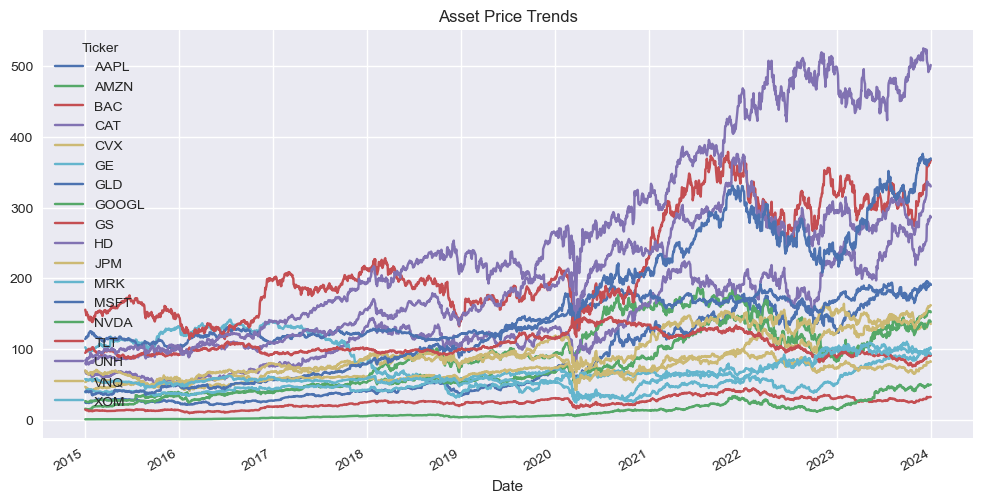

In [5]:
# ==================================================
# Price Trend Visualization
# ==================================================

data.plot(figsize=(12,6))
plt.title("Asset Price Trends")
plt.show()

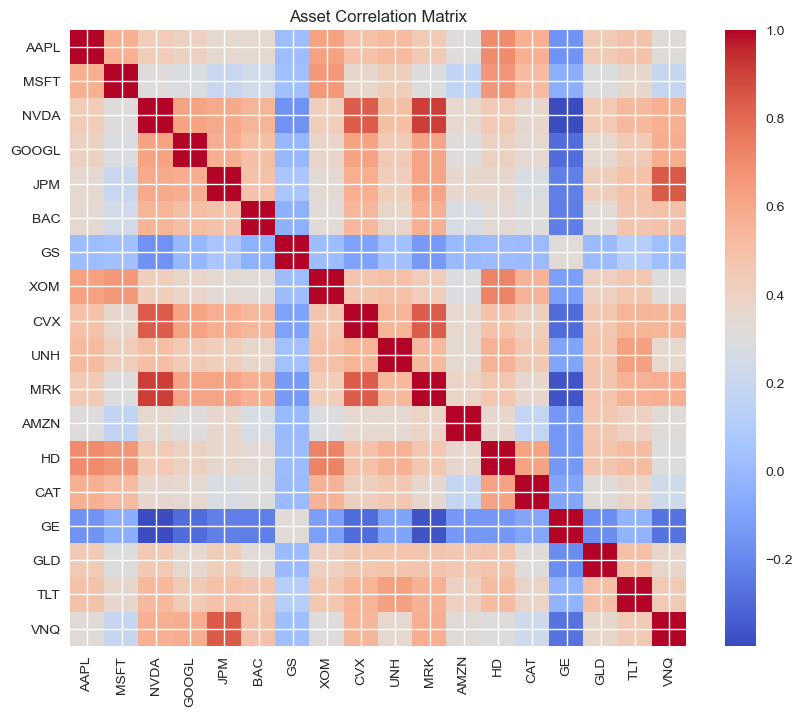

In [6]:
# ==================================================
# Correlation Analysis
# ==================================================

corr = returns.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Asset Correlation Matrix")
plt.xticks(range(len(tickers)), tickers, rotation=90)
plt.yticks(range(len(tickers)), tickers)
plt.show()

In [7]:
# ==================================================
# Momentum Signal
# ==================================================

momentum = data.pct_change(252)

momentum_scores = momentum.iloc[-1]

momentum_scores = momentum_scores.sort_values(ascending=False)

momentum_scores

Ticker
NVDA     2.529779
GE       1.000578
AMZN     0.857003
GOOGL    0.623925
MSFT     0.617594
AAPL     0.536069
JPM      0.322440
CAT      0.260435
GS       0.167590
GLD      0.138527
VNQ      0.134753
HD       0.128158
BAC      0.059456
TLT      0.027783
UNH      0.011252
MRK      0.008917
XOM     -0.046009
CVX     -0.124078
Name: 2023-12-29 00:00:00, dtype: float64

In [8]:
# ==================================================
# Portfolio Statistics
# ==================================================

mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

num_assets = len(tickers)

In [9]:
# ==================================================
# Portfolio Performance Function
# ==================================================

def portfolio_performance(weights):

    ret = np.sum(mean_returns * weights)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    return ret, vol

risk_free = 0.02



In [10]:
# ==================================================
# Sharpe Ratio Function
# ==================================================

risk_free = 0.02

def neg_sharpe(weights):

    ret, vol = portfolio_performance(weights)

    sharpe = (ret - risk_free) / vol

    return -sharpe

In [11]:
# ==================================================
# Optimization Constraints
# ==================================================

constraints = ({"type":"eq","fun": lambda x: np.sum(x) - 1})

bounds = tuple((0,1) for asset in range(num_assets))

init_guess = num_assets * [1./num_assets]

In [12]:
# ===============================
# Portfolio Optimization
# ===============================

opt = minimize(
    neg_sharpe,
    init_guess,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = opt.x

In [25]:
# ==================================================
# Portfolio Weights
# ==================================================

portfolio = pd.DataFrame({

"Stock": tickers,
"Weight": optimal_weights

})

portfolio = portfolio.sort_values("Weight", ascending=False)

portfolio

,Stock,Weight
6,GS,3.159393e-01
13,CAT,2.976844e-01
15,GLD,2.023777e-01
1,MSFT,8.354443e-02
11,AMZN,7.812668e-02
3,GOOGL,1.736061e-02
14,GE,4.966845e-03
0,AAPL,1.531452e-16
8,CVX,1.029158e-16
17,VNQ,7.204158e-17


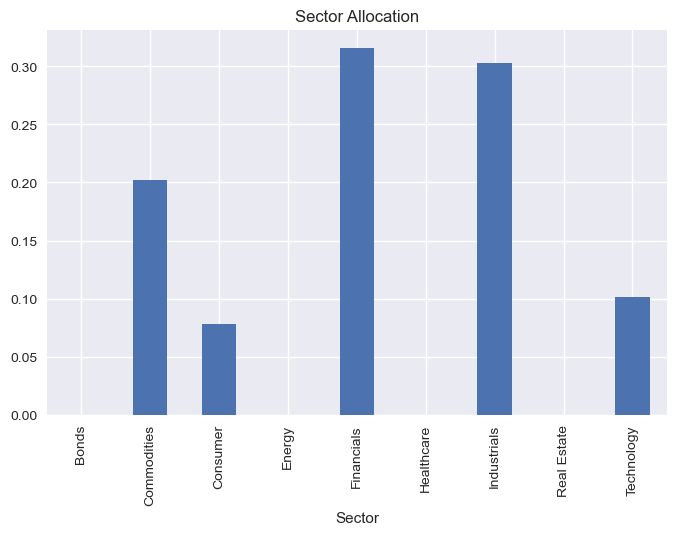

In [26]:
# ==================================================
# Sector Allocation Analysis
# ==================================================

sector_map = {

"AAPL":"Technology","MSFT":"Technology","NVDA":"Technology","GOOGL":"Technology",

"JPM":"Financials","BAC":"Financials","GS":"Financials",

"XOM":"Energy","CVX":"Energy",

"UNH":"Healthcare","MRK":"Healthcare",

"AMZN":"Consumer","HD":"Consumer",

"CAT":"Industrials","GE":"Industrials",

"GLD":"Commodities","TLT":"Bonds","VNQ":"Real Estate"
}

portfolio["Sector"] = portfolio["Stock"].map(sector_map)

sector_alloc = portfolio.groupby("Sector")["Weight"].sum()

sector_alloc.plot(kind="bar", figsize=(8,5))
plt.title("Sector Allocation")
plt.show()

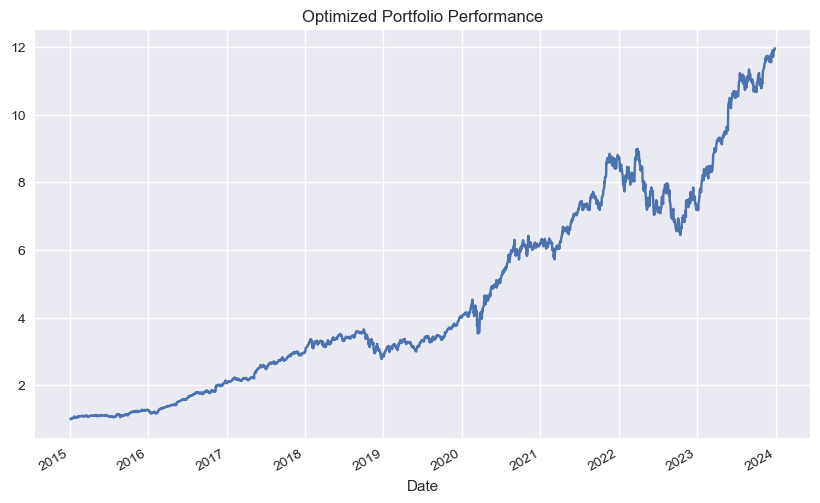

In [27]:
# ==================================================
# Portfolio Returns
# ==================================================

portfolio_returns = returns.dot(optimal_weights)

cumulative_returns = (1 + portfolio_returns).cumprod()

cumulative_returns.plot(figsize=(10,6))
plt.title("Optimized Portfolio Performance")
plt.show()

In [28]:
# ==================================================
# Benchmark Data
# ==================================================

benchmark = yf.download("SPY", start=start, end=end)["Close"]

benchmark_returns = benchmark.pct_change().dropna()

benchmark_cum = (1 + benchmark_returns).cumprod()

[*********************100%***********************]  1 of 1 completed


In [33]:
# ==================================================
# Portfolio Beta vs Market
# ==================================================

benchmark_returns = benchmark_returns.loc[portfolio_returns.index]

if isinstance(benchmark_returns, pd.DataFrame):
    benchmark_returns = benchmark_returns.squeeze()

port = portfolio_returns.values
bench = benchmark_returns.values

cov_matrix_beta = np.cov(port, bench)

covariance = cov_matrix_beta[0,1]
market_variance = cov_matrix_beta[1,1]

beta = covariance / market_variance

print("Portfolio Beta:", round(beta,3))

Portfolio Beta: 0.854


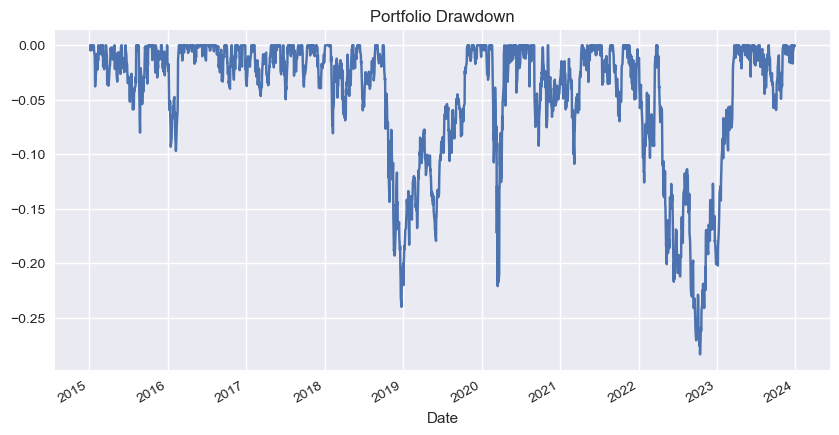

Max Drawdown: -0.284


In [35]:
# ==================================================
# Drawdown Analysis
# ==================================================

cum_max = cumulative_returns.cummax()

drawdown = (cumulative_returns - cum_max) / cum_max

drawdown.plot(figsize=(10,5))
plt.title("Portfolio Drawdown")
plt.show()

max_drawdown = drawdown.min()

print("Max Drawdown:", round(max_drawdown,3))

In [37]:
# ==================================================
# Risk Contribution Analysis
# ==================================================

portfolio_var = np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights))

marginal = np.dot(cov_matrix, optimal_weights)

risk_contribution = optimal_weights * marginal / portfolio_var

risk_df = pd.DataFrame({

"Asset": tickers,
"Risk Contribution": risk_contribution

}).sort_values("Risk Contribution", ascending=False)

risk_df

,Asset,Risk Contribution
13,CAT,6.586644e-01
15,GLD,1.564596e-01
1,MSFT,8.777109e-02
6,GS,5.418802e-02
11,AMZN,3.157850e-02
3,GOOGL,1.156437e-02
0,AAPL,1.458178e-16
8,CVX,7.495055e-17
12,HD,5.311406e-17
9,UNH,4.129828e-17


In [41]:
# ==================================================
# Rolling Portfolio Rebalancing with Weight Tracking
# ==================================================

rebalance_period = 63

rolling_returns = []
weight_history = []

for i in range(rebalance_period, len(returns)):

    window_returns = returns.iloc[i-rebalance_period:i]

    mean_returns_window = window_returns.mean()*252
    cov_matrix_window = window_returns.cov()*252

    def portfolio_perf(weights):
        ret = np.sum(mean_returns_window * weights)
        vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_window, weights)))
        return ret, vol

    def neg_sharpe_window(weights):
        ret, vol = portfolio_perf(weights)
        return -(ret-risk_free)/vol

    constraints = ({"type":"eq","fun":lambda x: np.sum(x)-1})
    bounds = tuple((0,1) for asset in range(num_assets))
    init_guess = num_assets * [1./num_assets]

    opt = minimize(
        neg_sharpe_window,
        init_guess,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    weights = opt.x

    weight_history.append(weights)

    daily_return = np.dot(returns.iloc[i], weights)

    rolling_returns.append(daily_return)


rolling_returns = pd.Series(
    rolling_returns,
    index=returns.index[rebalance_period:]
)

rolling_cumulative = (1 + rolling_returns).cumprod()

In [42]:
# ==================================================
# Portfolio Weight Evolution
# ==================================================

weights_df = pd.DataFrame(
    weight_history,
    columns=tickers,
    index=returns.index[rebalance_period:]
)

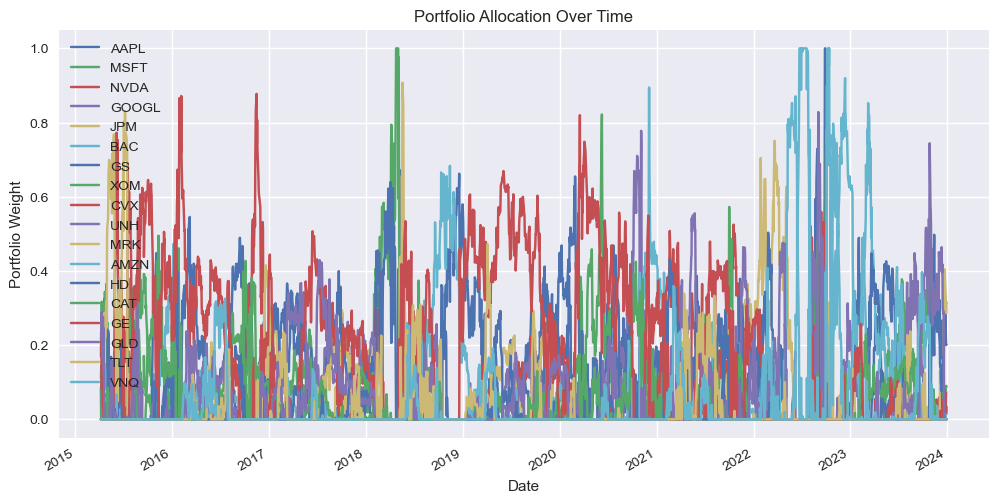

In [43]:
# ==================================================
# Portfolio Allocation Over Time
# ==================================================

weights_df.plot(figsize=(12,6))

plt.title("Portfolio Allocation Over Time")
plt.ylabel("Portfolio Weight")

plt.show()

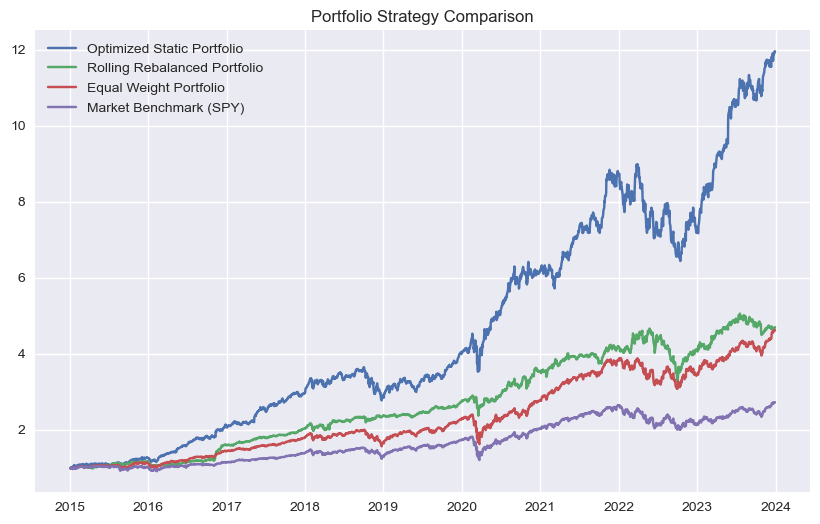

In [47]:
# ==================================================
# Strategy Comparison
# Static vs Rebalanced vs Equal Weight vs Benchmark
# ==================================================

equal_weights = np.repeat(1/num_assets, num_assets)

equal_returns = returns.dot(equal_weights)
equal_cum = (1 + equal_returns).cumprod()

plt.figure(figsize=(10,6))

plt.plot(cumulative_returns, label="Optimized Static Portfolio")
plt.plot(rolling_cumulative, label="Rolling Rebalanced Portfolio")
plt.plot(equal_cum, label="Equal Weight Portfolio")
plt.plot(benchmark_cum, label="Market Benchmark (SPY)")

plt.legend()
plt.title("Portfolio Strategy Comparison")
plt.show()

In [49]:
# ==================================================
# Portfolio Performance Metrics
# ==================================================

opt_return = portfolio_returns.mean() * 252
opt_vol = portfolio_returns.std() * np.sqrt(252)

opt_sharpe = (opt_return - risk_free) / opt_vol

print("Annual Return:", round(opt_return,3))
print("Volatility:", round(opt_vol,3))
print("Sharpe Ratio:", round(opt_sharpe,3))
print("Max Drawdown:", round(max_drawdown,3))

Annual Return: 0.296
Volatility: 0.198
Sharpe Ratio: 1.395
Max Drawdown: -0.284


In [51]:
# ==================================================
# Portfolio Summary
# ==================================================

summary = pd.DataFrame({

"Metric":[
"Annual Return",
"Volatility",
"Sharpe Ratio",
"Max Drawdown"
],

"Value":[
opt_return,
opt_vol,
opt_sharpe,
max_drawdown
]

})

summary

,Metric,Value
0,Annual Return,0.295958
1,Volatility,0.197767
2,Sharpe Ratio,1.395373
3,Max Drawdown,-0.283514


## Final Summary

This project develops a portfolio analytics framework to analyze portfolio construction strategies using historical market data. The analysis combines momentum signals, mean variance optimization and risk diagnostics to evaluate how capital can be allocated across a diversified set of assets.

The optimized portfolio demonstrates strong risk adjusted performance relative to the market benchmark, while sector diversification helps manage volatility and drawdowns. Risk contribution analysis highlights that a small number of assets often drive a large share of portfolio risk, reinforcing the importance of diversification and monitoring.

Strategy comparison further shows that the static optimized portfolio outperformed the rolling rebalanced strategy during the sample period, as strong momentum in leading assets allowed winning positions to compound without periodic reallocation.

Overall, the framework illustrates how systematic data analysis can support portfolio construction, capital allocation decisions and risk evaluation within a diversified investment portfolio.